## Multi Head Attention Mechanism

1. The term "multi-head" refers to dividing the attention mechanism into multiple heads.
2. 1 set of query, key and value is known as one head
3. Each head operating independently

what we do in Multi head Attention 

a. Stacking multiple single head attention layers <br>
    1. Implementing multi-head attention involves creating multiple instances of the self attention mechanism, each with its own weights and then combining their outputs <br>
    2. This can be computationally intensive, but it makes LLMs powerful at complex pattern recognition tasks 


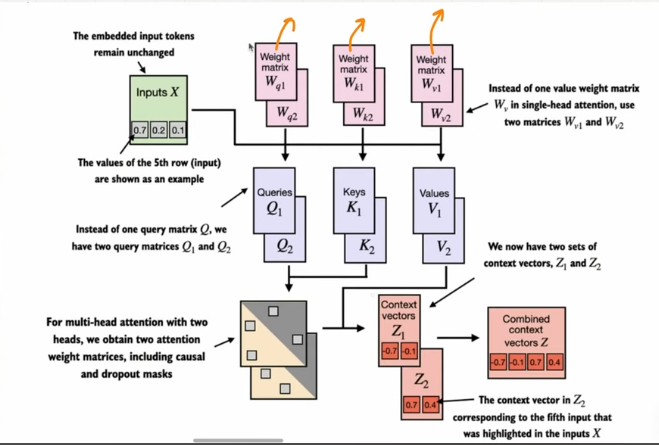

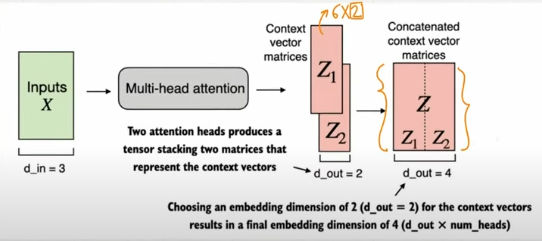

<b>Main Idea: </b> Run the attention mechanism multiple times (in parallel) with different, learned linear projections(the result of multiplying input data like key, query, value vectors by a weight matrix).

### EXTENDING SINGLE HEAD ATTENTION TO MULTI-HEAD ATTENTION

In practical terms, implementing multi-head attention involves creating multiple instances of the self-attention mechanism, each with its own weights, and then combining their outputs


In code, we can achieve this by implementing a simple MultiHeadAttentionWrapper class that stacks multiple instances of our previously implemented CausalAttention module:

In [3]:
import torch
from torch import nn

class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

In [4]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)   

batch = torch.stack((inputs, inputs), dim=0)
d_in = 3
d_out = 2

torch.manual_seed(123)
context_length = batch.shape[1]
print(batch.shape)
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)
print(context_vecs)

torch.Size([2, 6, 3])
context_vecs.shape: torch.Size([2, 6, 2])
tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


In [5]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


For example, if we use this MultiHeadAttentionWrapper class with two attention heads (via num_heads=2) and CausalAttention output dimension d_out=2, this results in a 4- dimensional context vectors (d_out*num_heads=4)

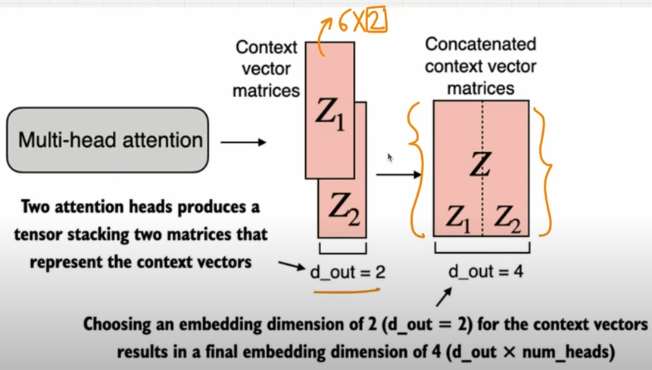

In [7]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("-"*100)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
----------------------------------------------------------------------------------------------------
context_vecs.shape: torch.Size([2, 6, 4])


The first dimension of the resulting context_vecs tensor is 2 since we have two input texts (the input texts are duplicated, which is why the context vectors are exactly the same for those).

The second dimension refers to the 6 tokens in each input. The third dimension refers to the 4-dimensional embedding of each token.

In this section, we implemented a MultiHeadAttentionWrapper that combined multiple single-head attention modules.
However, note that these are processed sequentially via [head(x) for head in self.heads] in the forward method.

We can improve this implementation by processing the heads in parallel.

One way to achieve this is by computing the outputs for all attention heads simultaneously via matrix multiplication, as we will explore in the next section.

### Optimized Approach for Multi Head

The problem with the prev approach is that suppose we have 96 attention heads as GPT-3 have. On the first stage only we will have to do 96 multiplication for each matrix and for each token. Like for a single token we will have to do 96 multiplications in order to get all 96 query matrices, then similarly with key and value matirces which is not at all useful and optimal.

So we will use a way where we will just to do the marix multiplication once. Then will seperate them into seperate matrices.

<b>This procedure is called Multi-Head Attention with weight splits.</b>

### Implementing Multi-Head Attention with weight splits.

1. Instead of maintaining 2 seperate classes: MultiHeadWrapper and CasualAttention, we combined both of these into a single MultiHeadAttention Class.

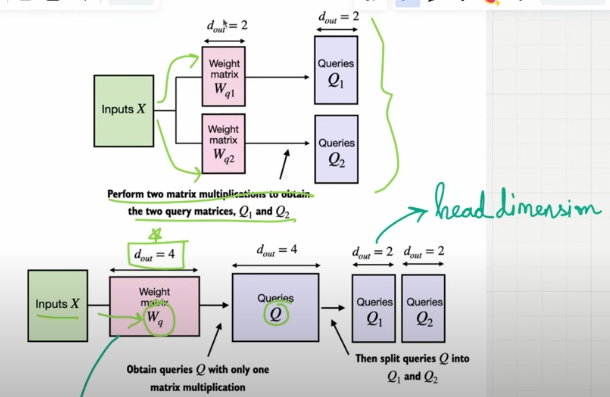
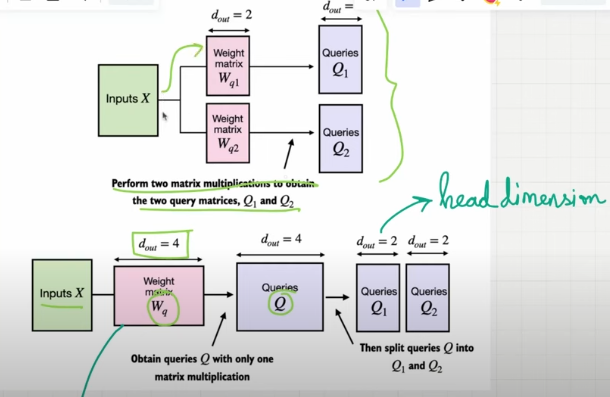

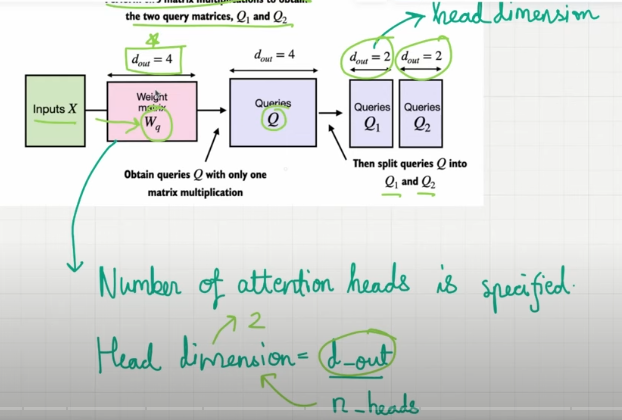

Instead of maintaining two separate classes, MultiHeadAttentionWrapper and CausalAttention, we can combine both of these concepts into a single MultiHeadAttention class.

Also, in addition to just merging the MultiHeadAttentionWrapper with the CausalAttention code, we will make some other modifications to implement multi-head attention more efficiently.

In the MultiHeadAttentionWrapper, multiple heads are implemented by creating a list of CausalAttention objects (self.heads), each representing a separate attention head.

The CausalAttention class independently performs the attention mechanism, and the results from each head are concatenated.

In contrast, the following MultiHeadAttention class integrates the multi-head functionality within a single class.

It splits the input into multiple heads by reshaping the projected query, key, and value tensors and then combines the results from these heads after computing attention.

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

### We Will understnd the code in forward function step by step 

1. def forward(self, x):<br>
    The forward func takes x as an input, What this x looks like?

     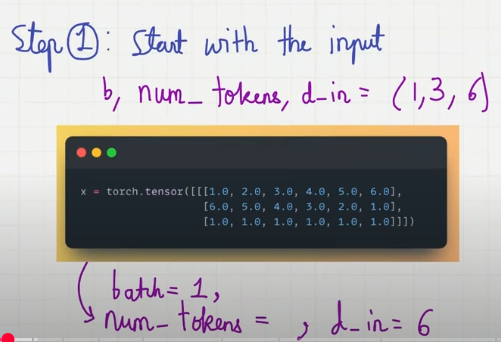

     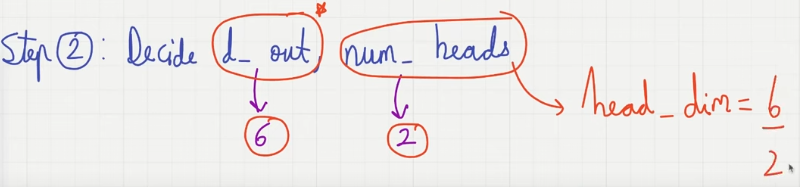

    d_out is the embedding-dimension of the context vector (6,6) last one

    d_in is the embedding-dimension of the input vector
    
    head_dim is the embedding dimension from each head, here we have 2 attention heads and the desired output_dimension is 6, so each of the attention head context vector should have 3 dimensions which will be concatenated toghehter to form the resultant context vector

    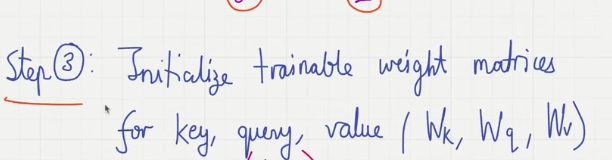

    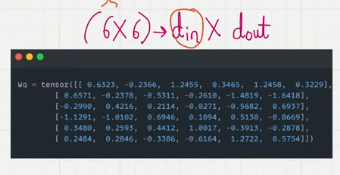

    these trainable matrices should be of the size d_in x d_out because the dimension of the input matrix and its rows should be same for matrix multiplication and d_out is to acheive the desired dimensionality in the context vector.

    These matrices are initialized in the init part of the code. 

    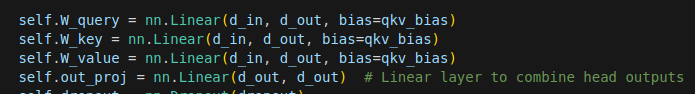

    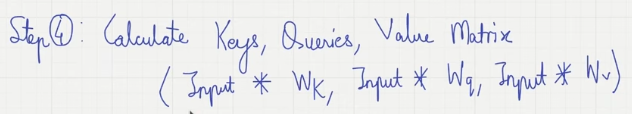

    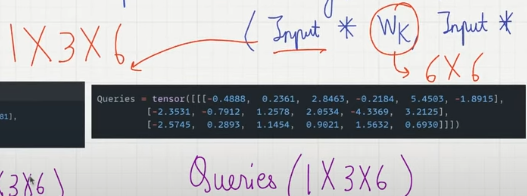

    The dimensions of the input vector is 1x3x6 and the dimension of Wk, Wq, Wv are 6x6, so the resultant key, query and value metrices will be 1x3x6.

    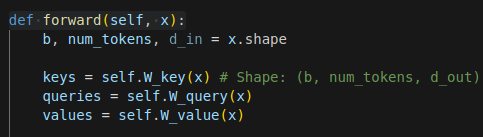

    Till now we have only three dimensions for batch, d_in and d_out. Now we will need to introduce another dimension that includes head_dim and num_heads

    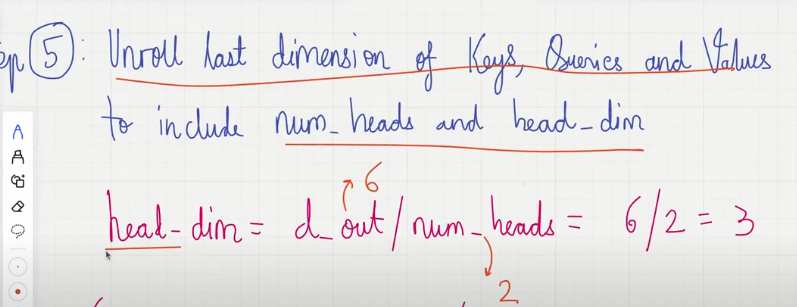

    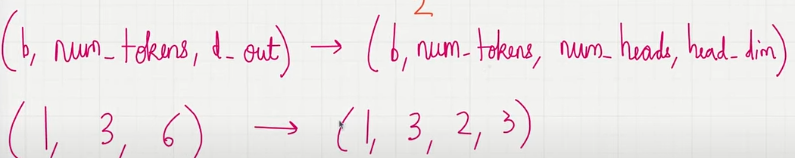

    Now instead of d_out we will have num_heads and head_dim which are calculated as above

    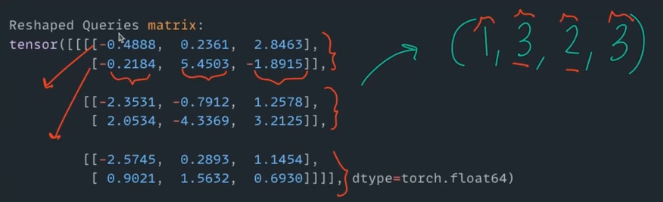

    For the shape (1,3,2,3)
    1. 1 -> batch size 
    2. 3 -> total number of multi dimension arrays, here three such arrays
    3. 2 -> dimensionality of those muti dimension arrays here it is 2 
    4. 3 -> no. of values in each array of the mutidimensions big array

    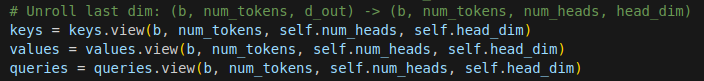

    Currently in the above query matrix image as you can see the matrics are grouped by tokens. i.e each token consist of values from its different attention i.e. (1,3,2,3). But what we want is to group these matrices on the basis of the attenion heads. i.e each attention head with all token values (1,2,3,3) -> two attention heads.

    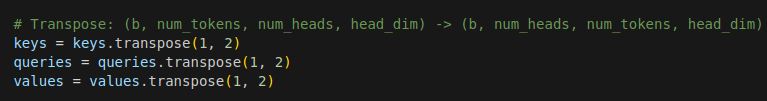

    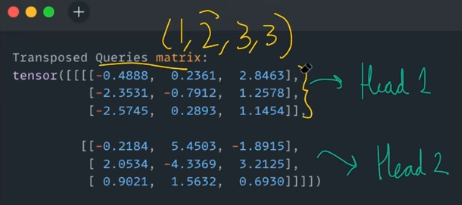

    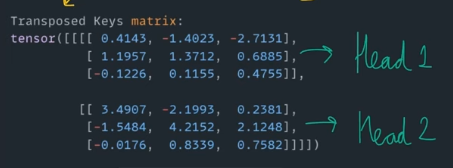

    As now we have grouped the values on the basis of the attention heads, it will now be easy to find the values of the attention scores parallely for each head.

    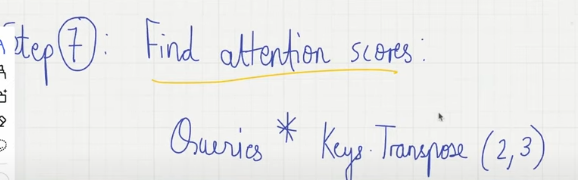

    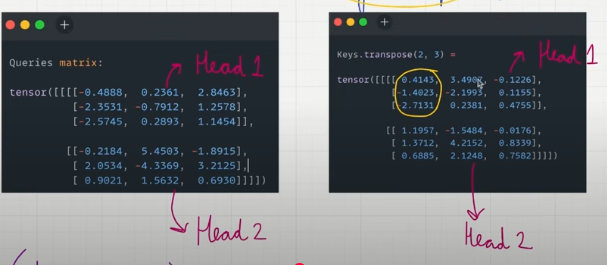

    Here is how the key matrix is been transposed 

    How the multiplication will be done is, the key matrix of head1 will only be multiplied with the query matrix of head1 and similarly with head2

    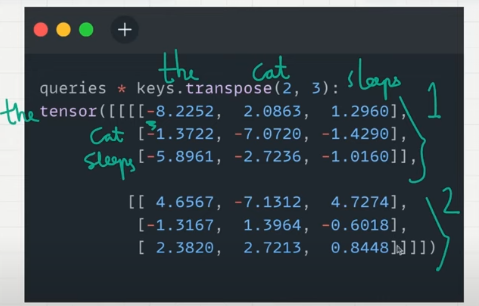

    These are the attention scores for different heads

    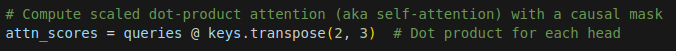

    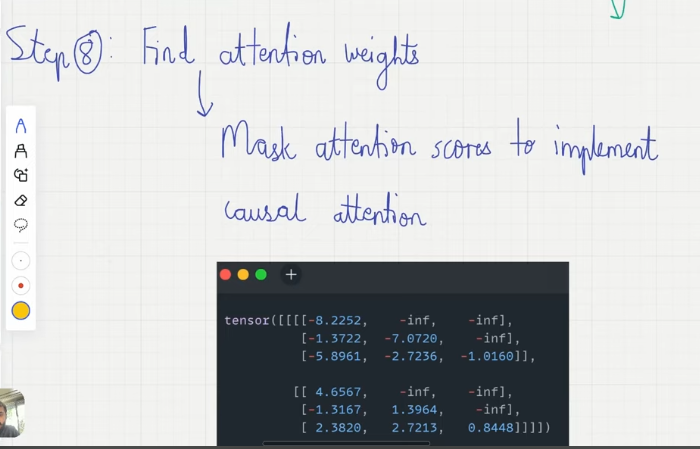

    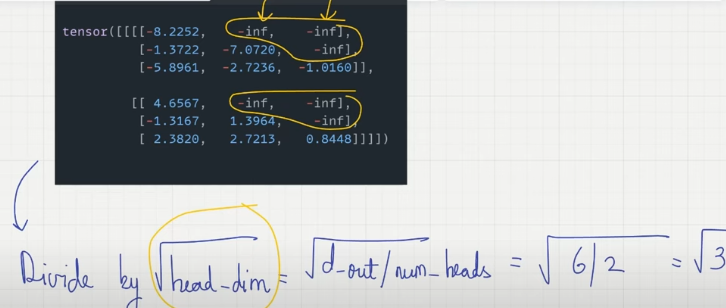

    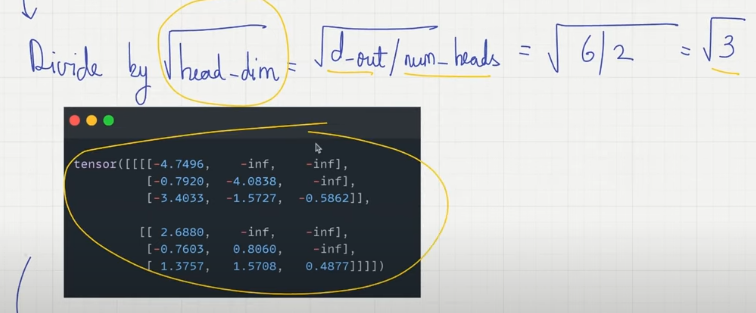

    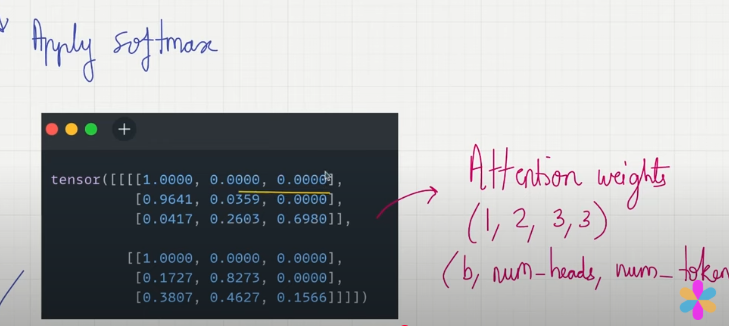

    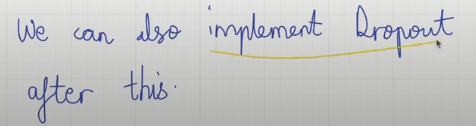

    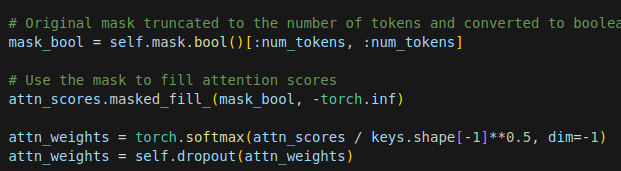

    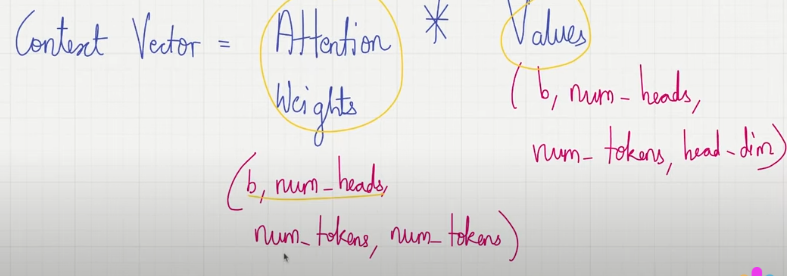

    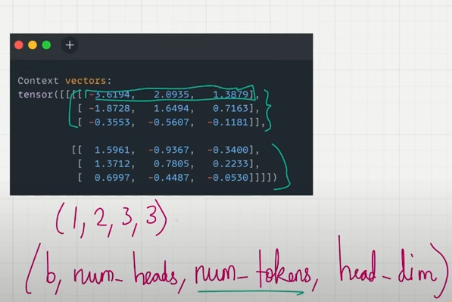
    
     Next we need tp Reformat context vectors: 

     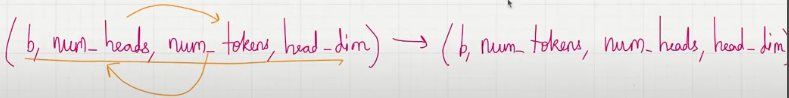
    
    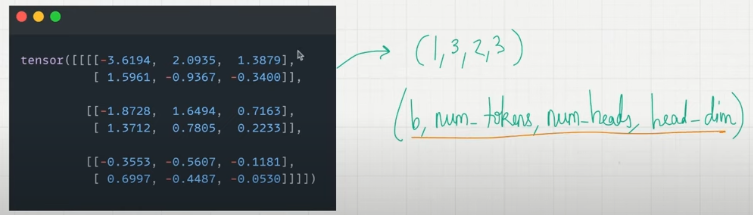

    All the above is done in a single line of code : 

    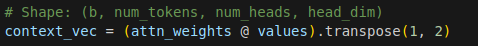

    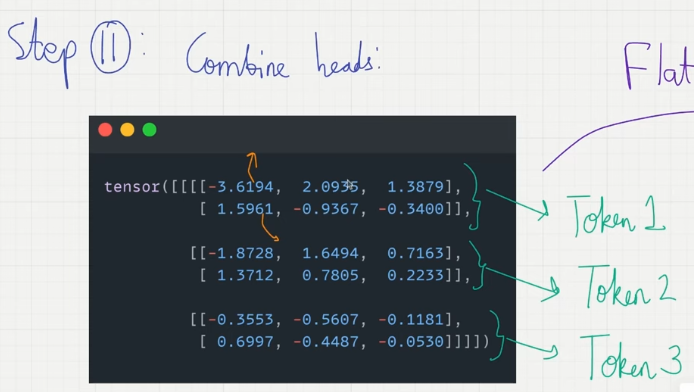

    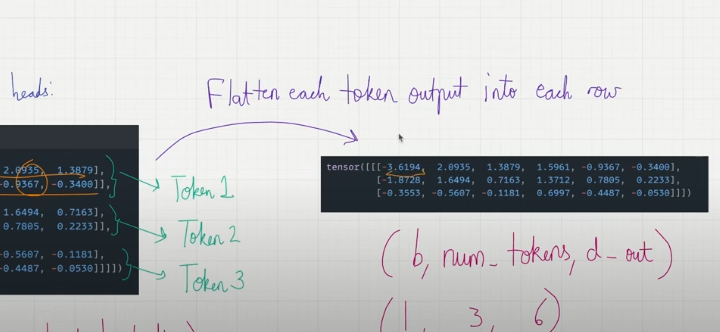

    This is the final answer in the shape as it was earlier 

    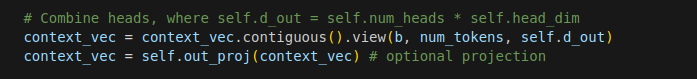

Step 1: Reduce the projection dim to match desired output dim

Step 2: Use a Linear layer to combine head outputs

Step 3: Tensor shape: (b, num_tokens, d_out)

Step 4: We implicitly split the matrix by adding a num_heads dimension. Then we unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)

Step 5: Transpose from shape (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)

Step 6: Compute dot product for each head

Step 7: Mask truncated to the number of tokens

Step 8: Use the mask to fill attention scores

Step 9: Tensor shape: (b, num_tokens, n_heads, head_dim)

Step 10: Combine heads, where self.d_out = self.num_heads * self.head_dim

Step 11: Add an optional linear projection


Even though the reshaping (.view) and transposing (.transpose) of tensors inside the MultiHeadAttention class looks very complicated, mathematically, the MultiHeadAttention class implements the same concept as the MultiHeadAttentionWrapper earlier.

On a big-picture level, in the previous MultiHeadAttentionWrapper, we stacked multiple single-head attention layers that we combined into a multi-head attention layer.

The MultiHeadAttention class takes an integrated approach.

It starts with a multi-head layer and then internally splits this layer into individual attention heads

### DETAILED EXPLANATION OF THE MULTI-HEAD ATTENTION CLASS

The splitting of the query, key, and value tensors, is achieved through tensor reshaping and transposing operations using PyTorch's .view and .transpose methods.

The input is first transformed (via linear layers for queries, keys, and values) and then reshaped to represent multiple heads.

The key operation is to split the d_out dimension into num_heads and head_dim, where head_dim = d_out / num_heads.

This splitting is then achieved using the .view method: a tensor of dimensions (b, num_tokens, d_out) is reshaped to dimension (b, num_tokens, num_heads, head_dim).

The tensors are then transposed to bring the num_heads dimension before the num_tokens dimension, resulting in a shape of (b, num_heads, num_tokens, head_dim).

This transposition is crucial for correctly aligning the queries, keys, and values across the different heads and performing batched matrix multiplications efficiently.

To illustrate this batched matrix multiplication, suppose we have the following example tensor:

In [9]:
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573], #A
[0.8993, 0.0390, 0.9268, 0.7388],
[0.7179, 0.7058, 0.9156, 0.4340]],
[[0.0772, 0.3565, 0.1479, 0.5331],
[0.4066, 0.2318, 0.4545, 0.9737],
[0.4606, 0.5159, 0.4220, 0.5786]]]])

In [10]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])
